In [1]:
import numpy as np
import matplotlib.pyplot as plt
from specs import *
from meer21cm import MockSimulation
from meer21cm.telescope import dish_beam_sigma
from scipy.optimize import curve_fit
from meer21cm.power import bin_3d_to_cy, bin_3d_to_1d
from matplotlib.colors import LogNorm
import glob
from astropy.cosmology import Planck18
import matplotlib.ticker as tck

In [2]:
def get_k_modes():
    mock = get_mock(0)    
    mock.downres_factor_transverse = ps_downres_transverse
    mock.downres_factor_radial = ps_downres_radial
    mock.get_enclosing_box()
    kperp_1 = mock.k_perp.copy()
    kpara_1 = mock.k_para.copy()
    kmode_1 = mock.k_mode.copy()
    kvec_1 = mock.k_vec.copy()
    return kperp_1, kpara_1, kmode_1, kvec_1

In [3]:
karr = get_k_modes()
kperp, kpara, kmode, kvec = karr

In [4]:
file_arr = glob.glob('/users/ztchen/scratch3/validation/full_sim_seed_*[0-9].npz')

In [5]:
k_xy_sel = (
    (np.abs(kvec[0])<0.04)[:,None,None] 
    * (np.abs(kvec[1])<0.04)[None,:,None]
    * (np.abs(kvec[2])<10)[None,None,:]
)
k_xy_sel[0] = 0.0
k_xy_sel[:,0] = 0.0
k_xy_sel[:,:,0] = 0.0
k_cy_sel = np.ones_like(k_xy_sel)
k_cy_sel[0] = 0.0
k_cy_sel[:,0] = 0.0
k_cy_sel[:,:,0] = 0.0

In [6]:
phi3d_arr = []
phimod3d_arr = []
pg3d_arr = []
pgmod3d_arr = []
pcross3d_arr = []
pcrossmod3d_arr = []
for file in file_arr:
    data = np.load(file)
    phi3d_arr.append(data['phi3d'])
    phimod3d_arr.append(data['phimod3d'])
    pg3d_arr.append(data['pg3d'])
    pgmod3d_arr.append(data['pgmod3d'])
    pcross3d_arr.append(data['pcross3d'])
    pcrossmod3d_arr.append(data['pcrossmod3d'])

In [7]:
phi3d_arr = np.array(phi3d_arr)
phimod3d_arr = np.array(phimod3d_arr)[0][None]
pg3d_arr = np.array(pg3d_arr)
pgmod3d_arr = np.array(pgmod3d_arr)[0][None]
pcross3d_arr = np.array(pcross3d_arr)
pcrossmod3d_arr = np.array(pcrossmod3d_arr)[0][None]

In [8]:
phimock_cy = get_cy(phi3d_arr,karr,weights=k_cy_sel)
pmodelcy_arr = get_cy(phimod3d_arr,karr,weights=k_cy_sel)
pgmock_cy = get_cy(pg3d_arr,karr,weights=k_cy_sel)
pgmodcy_arr = get_cy(pgmod3d_arr,karr,weights=k_cy_sel)
pcrossmock_cy = get_cy(pcross3d_arr,karr,weights=k_cy_sel)
pcrossmodcy_arr = get_cy(pcrossmod3d_arr,karr,weights=k_cy_sel)

/users/ztchen/meer21cm/src/meer21cm/power.py:2067: RuntimeWarning: invalid value encountered in divide
  pscy = pscy / np.sum(weights, 0)[None]


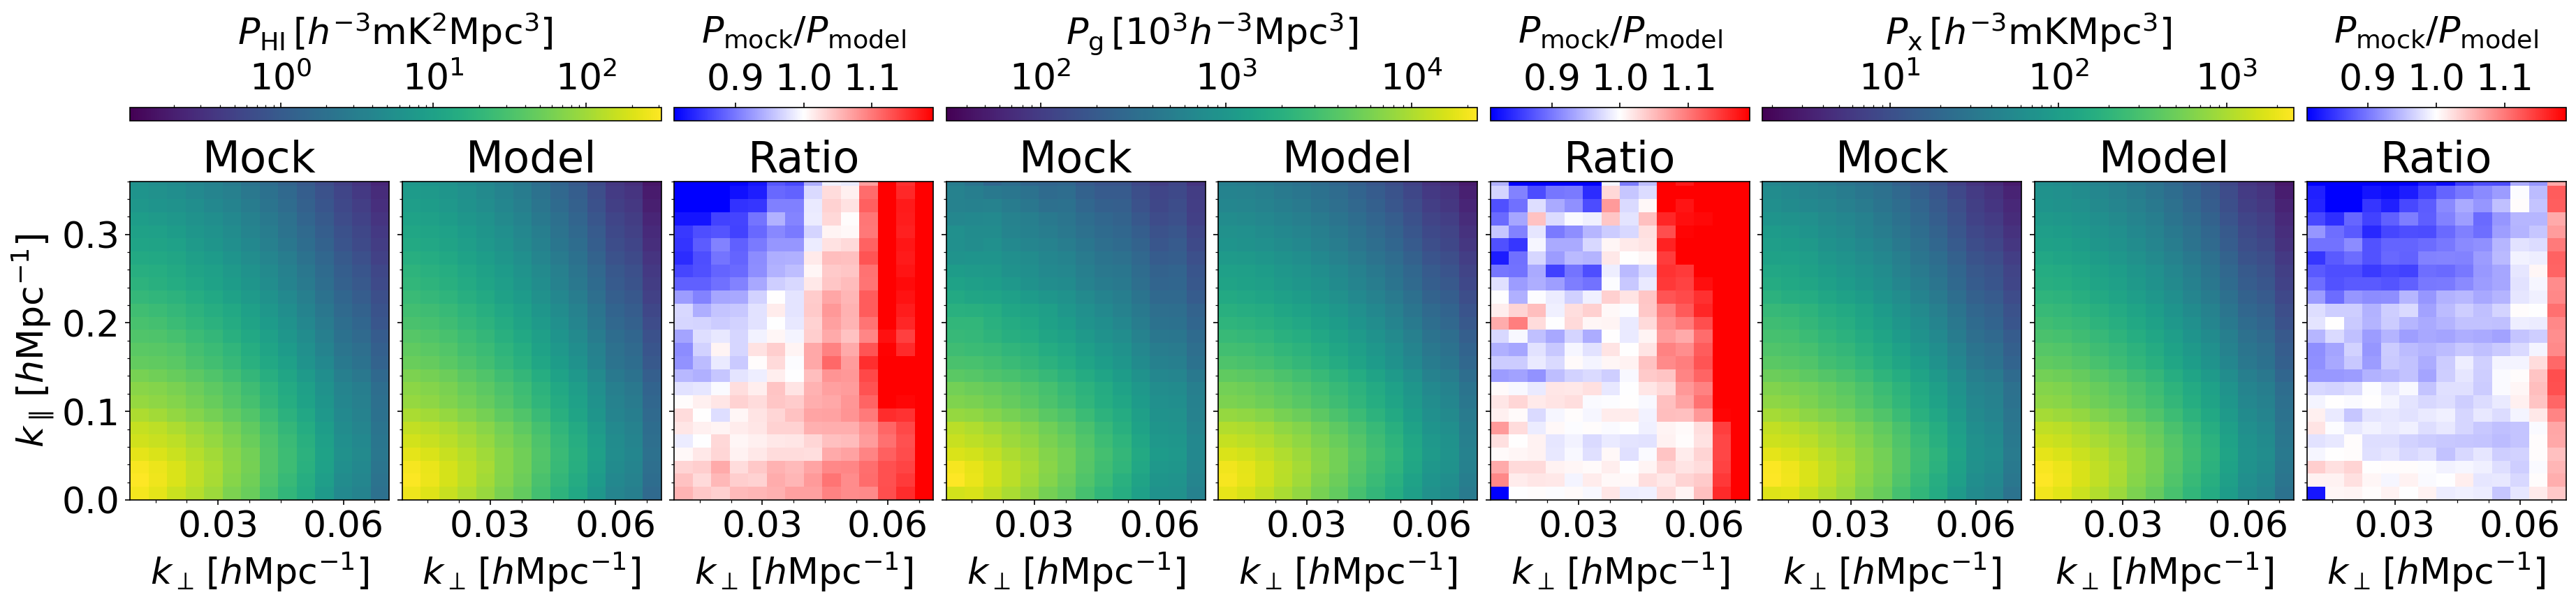

In [9]:
plt.rcParams['font.size'] = 25
fig, axes = plt.subplots(1, 9,figsize=(30,5),gridspec_kw={'wspace':0.05},dpi=150,)
pmockarr = [phimock_cy*1e6,pgmock_cy,pcrossmock_cy*1e3]
pmodelarr = [pmodelcy_arr*1e6,pgmodcy_arr,pcrossmodcy_arr*1e3]
pmockarr = np.array(pmockarr) * Planck18.h**3
pmodelarr = np.array(pmodelarr) * Planck18.h**3

ylabelarr= [
    r'$P_{\rm HI}\,[ h^{-3} {\rm mK^2 Mpc^3}]$',
    r'$P_{\rm g}\,[ 10^3 h^{-3}{\rm Mpc^3}]$',
    r'$P_{\rm x}\,[h^{-3} {\rm mK Mpc^3}]$',
]
for ax in axes:
    ax.set_ylim(0,0.36)
for i in range(3):
    xbins = kperpbins / Planck18.h
    ybins = kparabins / Planck18.h
    pdatacy = pmockarr[i]
    pmodcy = pmodelarr[i]
    arr = np.array([
        (pdatacy[:,:35].T),
        (pmodcy[:,:35].T),
    ])
    vmin = np.nanmin(arr)
    if vmin<0:
        vmin = 1
    vmax = np.nanmax(arr)
    axes[0+i*3].pcolormesh(
        xbins,
        ybins,
        (pdatacy.T),
        norm=LogNorm(vmin=vmin*2, vmax=vmax)
    )
    if i>0:
        axes[0+i*3].set_yticklabels([])
    else:
        axes[0+i*3].set_ylabel(r'$k_\parallel\,[h{\rm Mpc^{-1}}]$')
    axes[0+i*3].set_title(r'Mock')
    im = axes[1+i*3].pcolormesh(
        xbins,
        ybins,
        (pmodcy.T),
        norm=LogNorm(vmin=vmin*2, vmax=vmax)
    )
    axes[1+i*3].set_yticklabels([])
    axes[1+i*3].set_title(r'Model')
    
    cbar = plt.colorbar(im,ax=axes[0+i*3:2+i*3],location="top",fraction=0.06,pad=0.15,aspect=40)
    cbar.set_label(ylabelarr[i],labelpad=12)
    im = axes[2+i*3].pcolormesh(
        xbins,
        ybins,
        (pdatacy.T) / (pmodcy.T),
        #vmin=vmin_ratio,
        #vmax=vmax_ratio,
        vmin=0.81,
        vmax=1.19,
        cmap="bwr",
    )
    axes[2+i*3].set_yticklabels([])
    axes[2+i*3].set_title('Ratio')
    cbar = plt.colorbar(im,ax=axes[2+i*3],location="top",fraction=0.06,pad=0.15)
    cbar.set_label(r'$P_{\rm mock} / P_{\rm model}$',labelpad=14)
    for j in range(3):
        axes[j+i*3].set_xticks([0.03,0.06])
        axes[j+i*3].yaxis.set_minor_locator(tck.AutoMinorLocator())
        axes[j+i*3].xaxis.set_minor_locator(tck.AutoMinorLocator())
        
    
for ax in axes:
    ax.set_xlabel(r'$k_\perp\,[h{\rm Mpc^{-1}}]$')
plt.savefig('plots/01_cy.pdf',dpi=150, bbox_inches = "tight")

In [10]:
num_split = 20
pdata1darr, keff = get_1d(phi3d_arr,karr,weights=k_xy_sel,num_split=num_split)
pmod1darr, keff = get_1d(phimod3d_arr,karr,weights=k_xy_sel)
pg1darr, keff = get_1d(pg3d_arr,karr,weights=k_xy_sel,num_split=num_split)
pgmod1darr, keff = get_1d(pgmod3d_arr,karr,weights=k_xy_sel)
px1darr, keff = get_1d(pcross3d_arr,karr,weights=k_xy_sel,num_split=num_split)
pxmod1darr, keff = get_1d(pcrossmod3d_arr,karr,weights=k_xy_sel)

In [11]:
keff = keff / Planck18.h

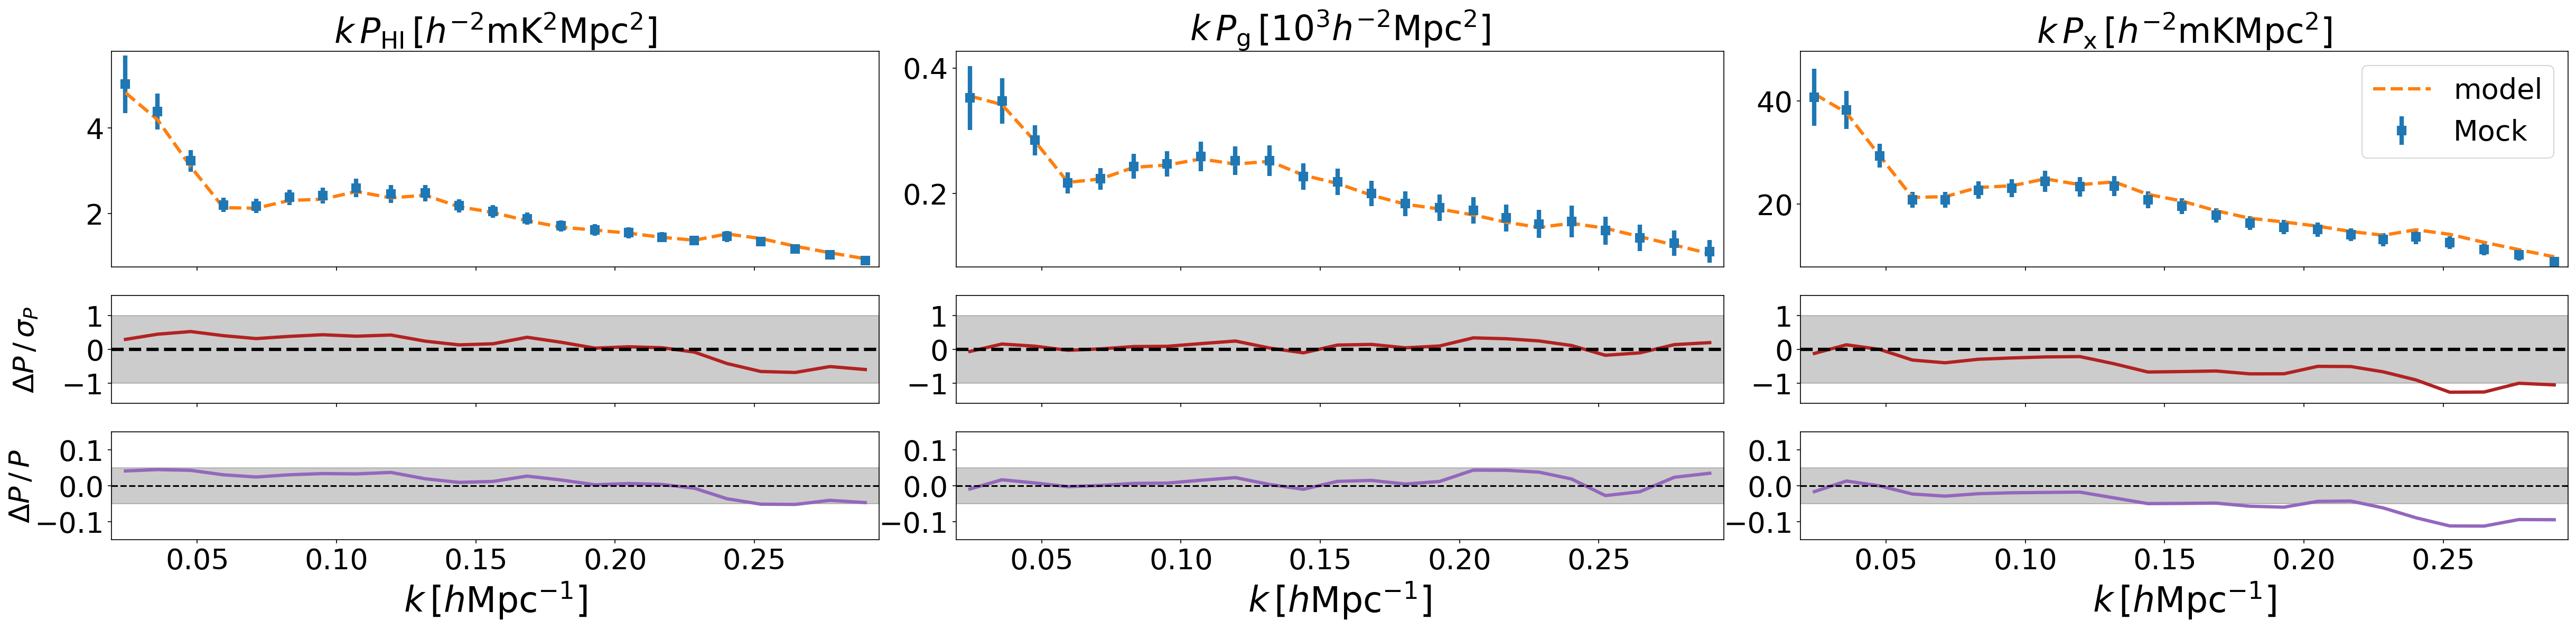

In [12]:
plt.rcParams['font.size'] = 26
fig,axes=plt.subplots(
    3,3,figsize=(40,8),sharex=True,
    height_ratios=[2,1,1],dpi=150,
    gridspec_kw={'wspace':0.1},
)
ratio_min,ratio_max = (-1.6,1.6)
pmockarr = [pdata1darr*1e6,pg1darr/1e3,px1darr*1e3]
pmodelarr = [pmod1darr*1e6,pgmod1darr/1e3,pxmod1darr*1e3]
pmockarr = np.array(pmockarr) * Planck18.h**3
pmodelarr = np.array(pmodelarr)[:,0] * Planck18.h**3
ylabelarr= [
    r'$k\,P_{\rm HI}\,[ h^{-2} {\rm mK^2 Mpc^2}]$',
    r'$k\,P_{\rm g}\,[ 10^3 h^{-2}{\rm Mpc^2}]$',
    r'$k\,P_{\rm x}\,[h^{-2} {\rm mKMpc^2}]$',
]
for i in range(3):
    pdatad = pmockarr[i]
    pmodd = pmodelarr[i]
    axes[0,i].errorbar(
        keff,
        pdatad.mean(axis=0) * keff,
        yerr=pdatad.std(axis=0) * keff / np.sqrt(10),
        label="Mock",
        ls='None',
        elinewidth=4,
        marker='s',
        markersize=8,
    )
    axes[0,i].plot(keff, pmodd * keff, label="model", ls="--",color='C1',lw=3)
    axes[0,i].set_ylim((pmodd * keff).min() * 0.8, (pmodd * keff).max() * 1.2)
    if i == 2:
        axes[0,i].legend()
    axes[0,i].set_title(ylabelarr[i])
    axes[1,i].plot(
        keff,
        (pdatad.mean(axis=0)- pmodd) / (pdatad.std(axis=0)) * np.sqrt(10),
        color='firebrick',
        lw=3,
    )
    axes[1,i].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -1,
        1,
        color="black",
        alpha=0.2,
    )
    axes[1,i].axhline(0, color="black", ls="--",lw=3)
    axes[1,i].set_xlim(keff.min()-0.005,keff.max()+0.005)
    axes[1,i].set_ylim(ratio_min,ratio_max)
    if i == 0:
        axes[1,i].set_ylabel(r'$\Delta P \, / \,\sigma_P$',labelpad=20)
    axes[2,i].plot(
        keff,
        (pdatad.mean(axis=0)) / (pmodd) - 1,
        lw=3,
        color='C4',
    )
    axes[2,i].axhline(0, color="black", ls="--")
    axes[2,i].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -0.05,
        0.05,
        color="black",
        alpha=0.2,
    )
    axes[2,i].set_xlim(keff.min() - 0.005, keff.max() + 0.005)
    axes[2,i].set_ylim(-0.15, 0.15)
    axes[2,i].set_xlabel(r'$k\,[h{\rm Mpc^{-1}}]$', fontsize=32)
    if i ==0:
        axes[2,i].set_ylabel(r'$\Delta P \, / \,P$',labelpad=-1)
        
plt.savefig('plots/01_1d.pdf',dpi=150, bbox_inches = "tight")